# Notebook di test dei metodi implementati

In [8]:
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Classe Tickers

[*********************100%***********************]  6 of 6 completed


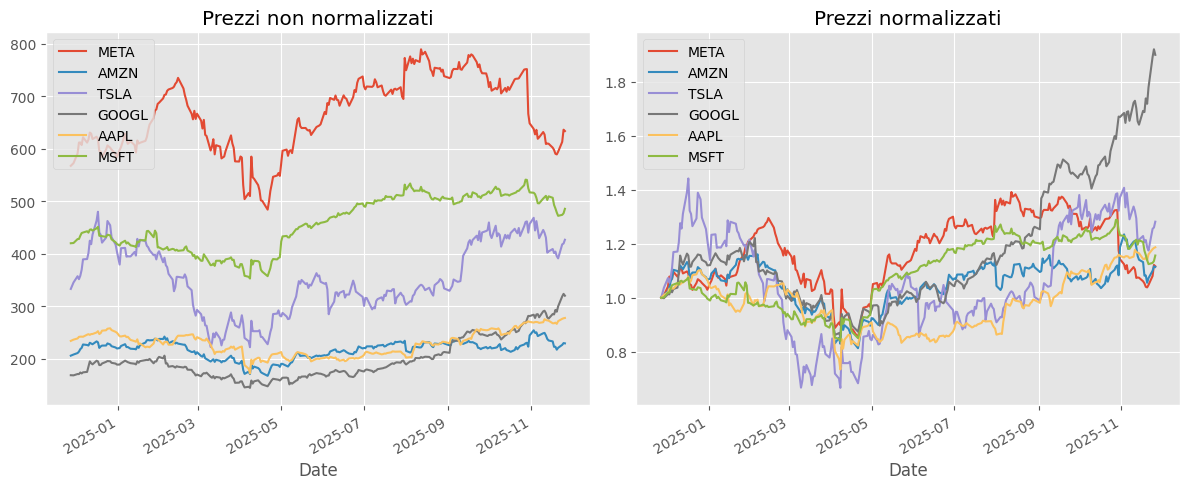

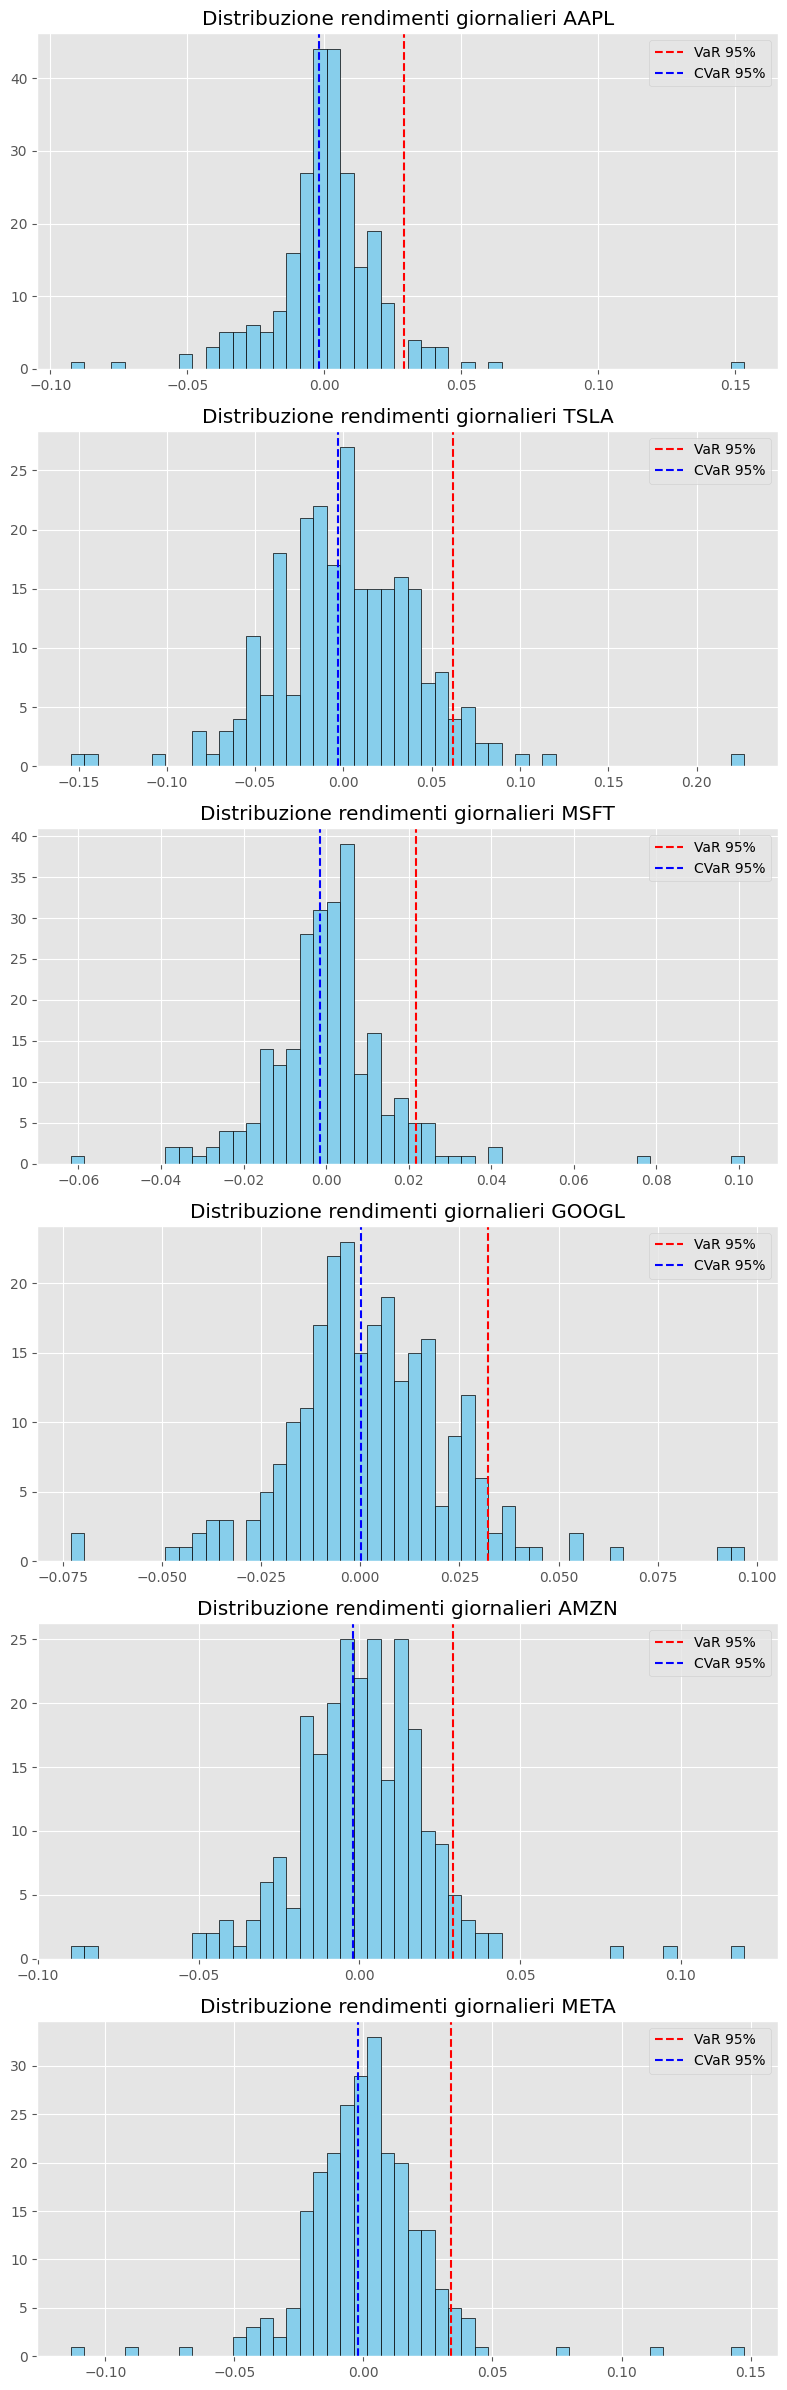

,Annual Returns,Annual Volatility,Max Drawdown,Sharpe Ratio,VaR (95%),VaR Cornish-Fischer (95%),CVaR (95%)
AAPL,0.187451,0.326670,0.367813,0.481990,-0.029187,-0.037303,0.001753
AMZN,0.114242,0.349483,0.363274,0.241048,-0.029064,-0.033028,0.002076
GOOGL,0.903113,0.333162,0.363906,2.620686,-0.032328,-0.044444,-0.000149
META,0.117079,0.383777,0.442343,0.226899,-0.033964,-0.040610,0.002311
MSFT,0.156820,0.243463,0.234495,0.520902,-0.021875,-0.026095,0.001372
TSLA,0.282527,0.654619,0.775031,0.385762,-0.061865,-0.072615,0.003055


In [9]:
from portfolio import Tickers

# classe istanziata fornendo una lista di asset, un periodo ed eventualmente un provider di dati
titoli = ['AAPL', 'TSLA', 'MSFT', 'GOOGL', 'AMZN', 'META']
dict_tickers = {"tickers": titoli, 'period': '1y'}
tickers_yf = Tickers(**dict_tickers)

# test plot (prezzi normalizzati e non)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
tickers_yf.plot(rescale=False, ax=ax1, title="Prezzi non normalizzati")
tickers_yf.plot(rescale=True, ax=ax2, title="Prezzi normalizzati")
fig.tight_layout()

# test plot distribuzione rendimenti giornalieri (con evidenziato VaR ed expected shortfall)
tickers_yf.plot_dailyret_dist()

# test _repr_html_
tickers_yf

In [10]:
# costruzione dati da altro provider (FMP)
from marketdata.fmp import FMPProvider
tickers_fmp = Tickers(**dict_tickers, provider=FMPProvider())

tickers_fmp

,Annual Returns,Annual Volatility,Max Drawdown,Sharpe Ratio,VaR (95%),VaR Cornish-Fischer (95%),CVaR (95%)
AAPL,0.176410,0.327171,0.364075,0.447501,-0.029517,-0.037336,0.001804
AMZN,0.103275,0.350048,0.359517,0.209329,-0.029104,-0.032987,0.002129
GOOGL,0.913064,0.333824,0.364485,2.645295,-0.032318,-0.044521,-0.000156
META,0.107708,0.384458,0.438395,0.202125,-0.034116,-0.040578,0.002359
MSFT,0.156453,0.243968,0.234252,0.518317,-0.021891,-0.026110,0.001382
TSLA,0.238236,0.654983,0.747479,0.317925,-0.061902,-0.072478,0.003225


In [11]:
"""
Nota: i numeri non sono perfettamente uguali se analizzo i dati coi due provider distinti.
Qui sotto analizzo i dati grezzi sulle azioni Apple.

Conclusione: è possibile che i diversi arrotondamenti e la diversa policy di troncamento del periodo
di 1y, con conseguente mancanza della data del valore di chiusura al 27/11/2024 per FMPProvider, abbiano
incorso in questi minimi spostamenti.

Da indagare.
"""

import pandas as pd
pd.concat([tickers_fmp.df['AAPL'], tickers_yf.df['AAPL']], axis=1)


,AAPL,AAPL
2024-11-27,NaN,233.872238
2024-11-29,236.27,236.261444
2024-12-02,238.52,238.511276
2024-12-03,241.56,241.557480
2024-12-04,241.92,241.915863
...,...,...
2025-11-20,266.25,266.250000
2025-11-21,271.49,271.489990
2025-11-24,275.92,275.920013
2025-11-25,276.97,276.970001


## Strategie di trading single-asset

[*********************100%***********************]  1 of 1 completed


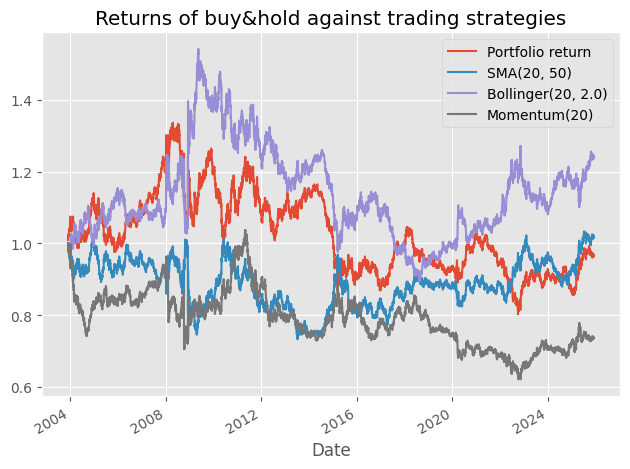

In [12]:
from backtesting.singleasset import SMA, Bollinger, Momentum

# analizzo strategie sul cambio euro-dollaro
eurusd = Tickers(tickers="EURUSD=X", period="max")

# confronto grafico strategie
SMA(eurusd).plot()
Bollinger(eurusd).plot()
Momentum(eurusd).plot()
plt.tight_layout()

## Analisi strategia CPPI su portafoglio

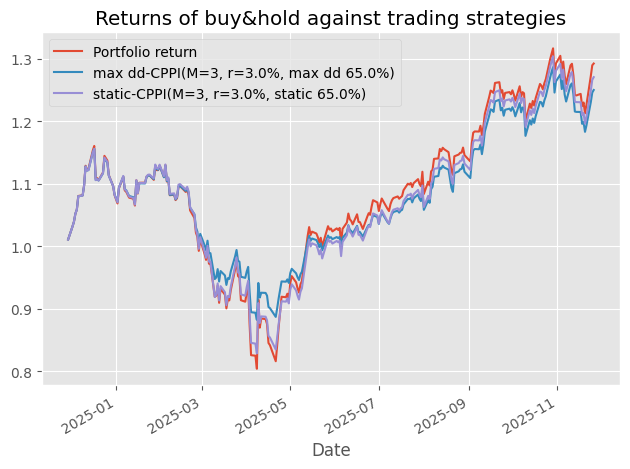

In [13]:
from portfolio import Portfolio
from backtesting.cppi import CPPI

# test ribilanciamento settimanale
CPPI(Portfolio(tickers_yf), floor=0.65, reb='W', type='max dd').plot()
CPPI(Portfolio(tickers_yf), floor=0.65, reb='W', type='static').plot()
plt.tight_layout()

<Axes: title={'center': 'max dd-CPPI(M=3, r=3.0%, max dd 65.0%)'}, xlabel='Date', ylabel='Return'>

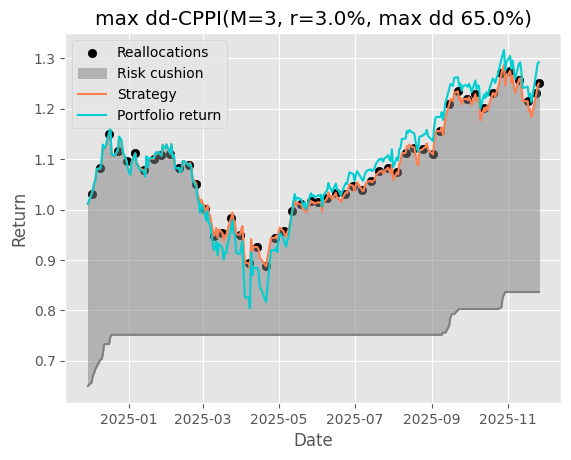

In [14]:
# test funzione di plot della parte allocata a rischio basso (risk-cushion)
CPPI(Portfolio(tickers_yf), floor=0.65, reb='W', type='max dd').plot_strategy_floor_rebalance()